In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('predict_results_from_gpt.csv')
df_original = pd.read_csv('../polygraphpy/data/polarizability_data.csv')

In [3]:
df_modified = df.iloc[1:]
df_modified.sort_values(by='error')

,smiles_A,y,pred,error
37,CCOC(=O)C=CC1=CN=C(N=C1N)SC,0.114613,0.115053,0.003836
55,CC1(COC2=C1C=C(C=C2)/C=C/C(=O)OC(C)(C)C)C,0.166189,0.167016,0.004976
106,C=CC(=O)OCCOC1=CC=C(C=C1)C2CC=CC(=C2F)C3=CC=CC...,0.315186,0.319287,0.013011
129,CCOC(=O)/C=C/C1=CC=C(C=C1)NC(=O)C2(CCCC2)NC(=O...,0.383954,0.389900,0.015486
133,C1=CC=C(C=C1)C2=CC=C(C=C2)CN(CC3=CC(=CC(=C3)C)...,0.395415,0.386816,0.021747
...,...,...,...,...
26,CC(=O)OCC1=CC=CC=C1,0.083095,0.406737,3.894873
3,C=CC(=O)OC(COC)(O)O,0.008596,0.071212,7.284360
2,C[N+1](C)(C)C.C=CC(=O)[O-1],0.005731,0.091747,15.009802
4,[2H]C(=O)C(=C)CNC1=CC=CS1,0.011461,0.271890,22.722427


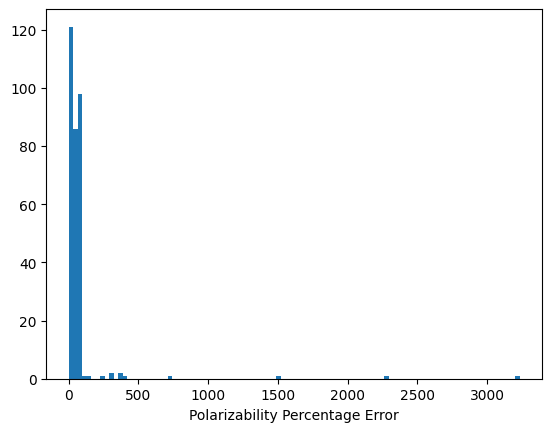

In [4]:
plt.hist(100*df_modified['error'], bins=100)
plt.xlabel('Polarizability Percentage Error')
plt.show()

100


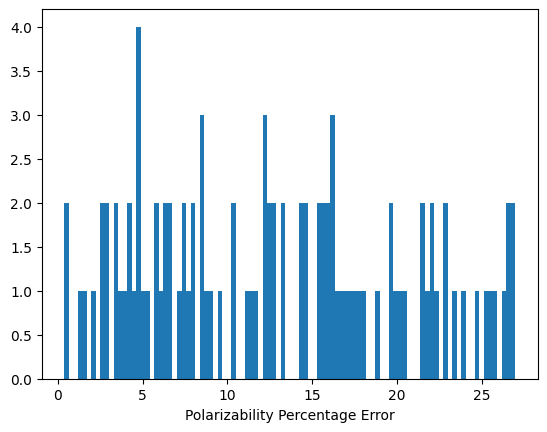

In [5]:
df_modified = df_modified.sort_values(by='error').head(100)
print(len(df_modified))

plt.hist(100*df_modified['error'], bins=100)
plt.xlabel('Polarizability Percentage Error')
plt.show()

In [6]:
100*df_modified['error'].describe()

count    10000.000000
mean        12.826676
std          7.542318
min          0.383611
25%          6.389214
50%         12.533457
75%         18.331057
max         26.964871
Name: error, dtype: float64

In [7]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error

df_error = pd.DataFrame({
            'mape': round(mean_absolute_percentage_error(df_modified.y.values, df_modified.pred.values) * 100, 5),
            'r2': round(r2_score(df_modified.y.values, df_modified.pred.values), 5),
            'mse': round(mean_squared_error(df_modified.y.values, df_modified.pred.values), 5)
        }, index=[0])
print(df_error)

       mape       r2      mse
0  12.82668  0.86618  0.00222


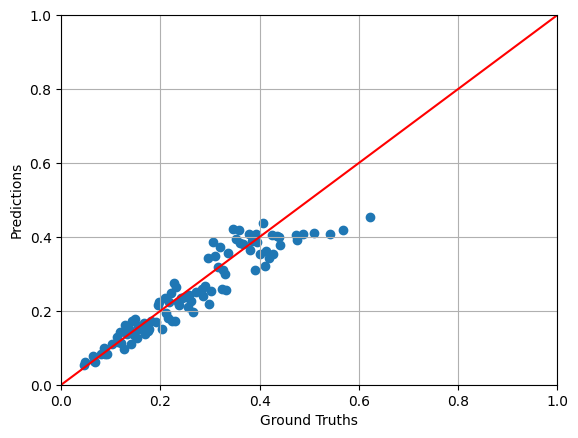

In [8]:
import numpy as np

p1 = [0, 1]
p2 = [0, 1]

coefficients = np.polyfit(p1, p2, 1)

polynomial = np.poly1d(coefficients)
x_axis = np.linspace(0, 1, 500)
y_axis = polynomial(x_axis)

fig = plt.figure()
plt.scatter(df_modified.y.values, df_modified.pred.values)
plt.plot(x_axis, y_axis, 'r')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(1)
plt.xlabel("Ground Truths")
plt.ylabel("Predictions")
plt.show()